In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df["Age"] = df["Age"].fillna(df["Age"].median())
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
print("Dataset ready:", df.shape)

Dataset ready: (891, 13)


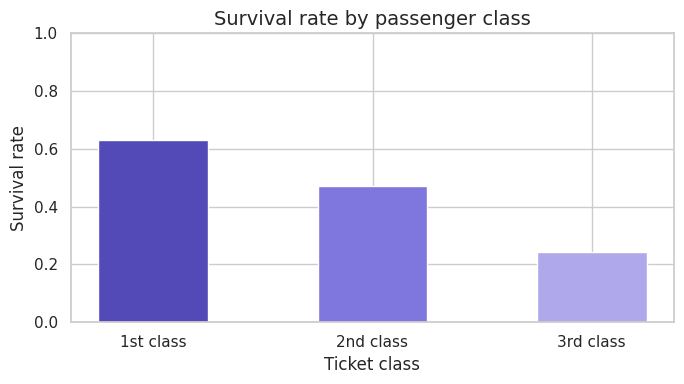

/tmp/ipykernel_6254/2194243457.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Pclass", y="Survived", palette="Blues_d")


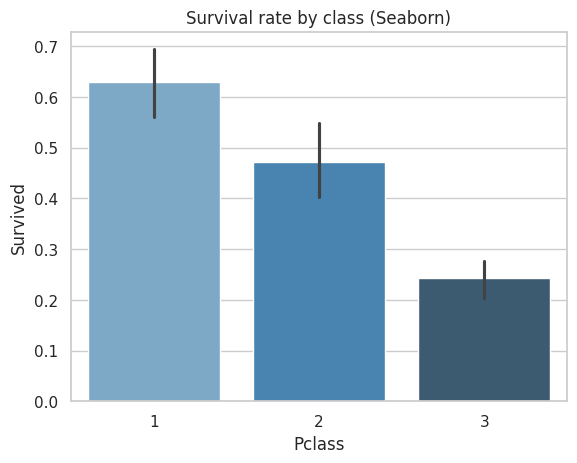

In [4]:
survival_by_class = df.groupby("Pclass")["Survived"].mean()

plt.figure(figsize=(7, 4))
plt.bar(survival_by_class.index, survival_by_class.values,
       color=["#534AB7", "#7F77DD", "#AFA9EC"], width=0.5)
plt.title("Survival rate by passenger class", fontsize=14)
plt.xlabel("Ticket class")
plt.ylabel("Survival rate")
plt.xticks([1, 2, 3], ["1st class", "2nd class", "3rd class"])
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Seaborn version — same chart, less code
sns.barplot(data=df, x="Pclass", y="Survived", palette="Blues_d")
plt.title("Survival rate by class (Seaborn)")
plt.show()

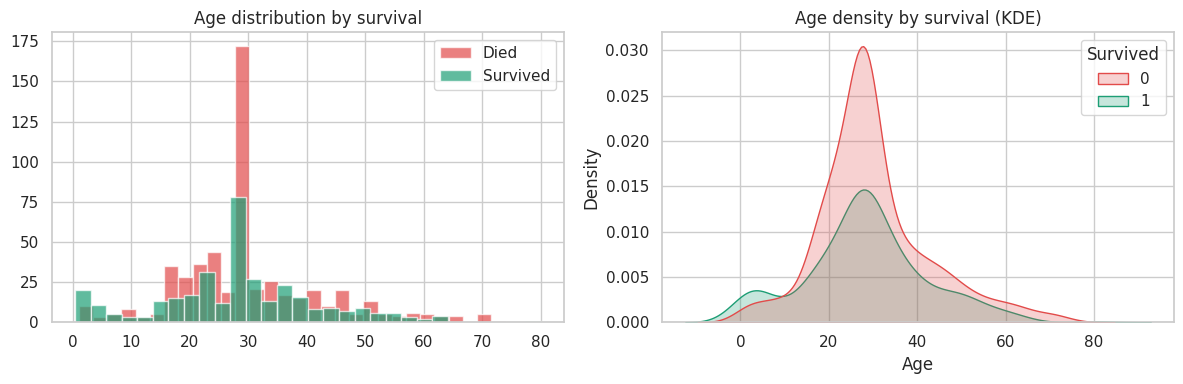

In [5]:
# Compare age distribution of survivors vs non-survivors
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Matplotlib histogram
axes[0].hist(df[df["Survived"]==0]["Age"], bins=30,
            alpha=0.7, color="#E24B4A", label="Died")
axes[0].hist(df[df["Survived"]==1]["Age"], bins=30,
            alpha=0.7, color="#1D9E75", label="Survived")
axes[0].set_title("Age distribution by survival")
axes[0].legend()

# Seaborn KDE plot — smoother version of histogram
sns.kdeplot(data=df, x="Age", hue="Survived",
            ax=axes[1], fill=True, palette=["#E24B4A","#1D9E75"])
axes[1].set_title("Age density by survival (KDE)")
plt.tight_layout()
plt.show()

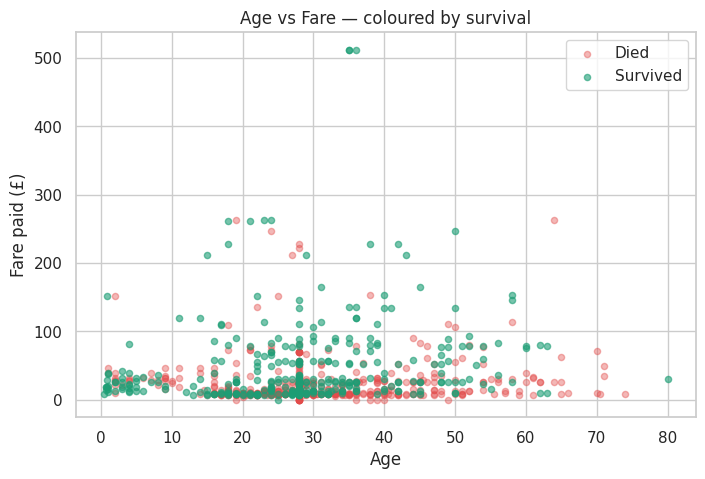

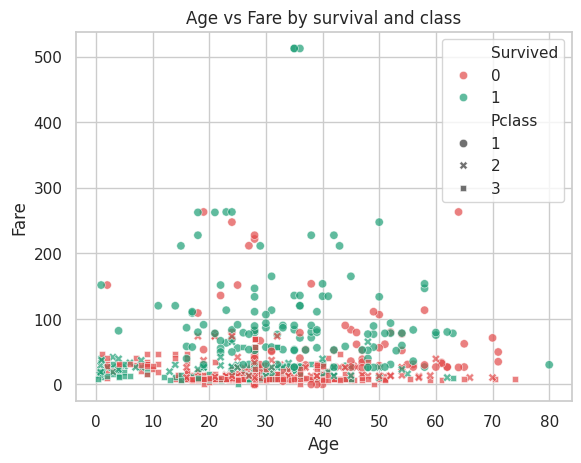

In [6]:
plt.figure(figsize=(8, 5))
survived    = df[df["Survived"]==1]
not_survived = df[df["Survived"]==0]

plt.scatter(not_survived["Age"], not_survived["Fare"],
            alpha=0.4, c="#E24B4A", label="Died", s=20)
plt.scatter(survived["Age"],     survived["Fare"],
            alpha=0.6, c="#1D9E75", label="Survived", s=20)
plt.xlabel("Age")
plt.ylabel("Fare paid (£)")
plt.title("Age vs Fare — coloured by survival")
plt.legend()
plt.show()

# Seaborn scatterplot — adds regression line in one parameter
sns.scatterplot(data=df, x="Age", y="Fare",
                hue="Survived", style="Pclass",
                palette=["#E24B4A","#1D9E75"], alpha=0.7)
plt.title("Age vs Fare by survival and class")
plt.show()


/tmp/ipykernel_6254/2437550028.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Pclass", y="Fare",
/tmp/ipykernel_6254/2437550028.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Survived", y="Age",
/tmp/ipykernel_6254/2437550028.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Died", "Survived"])


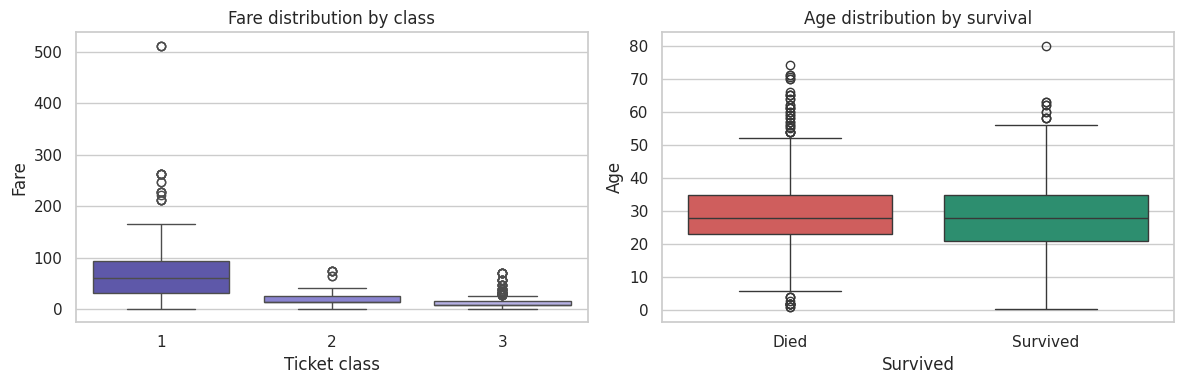

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Seaborn boxplot — effortless with DataFrames
sns.boxplot(data=df, x="Pclass", y="Fare",
            palette=["#534AB7","#7F77DD","#AFA9EC"], ax=axes[0])
axes[0].set_title("Fare distribution by class")
axes[0].set_xlabel("Ticket class")

# Age by survival — do survivors tend to be younger?
sns.boxplot(data=df, x="Survived", y="Age",
            palette=["#E24B4A","#1D9E75"], ax=axes[1])
axes[1].set_title("Age distribution by survival")
axes[1].set_xticklabels(["Died", "Survived"])
plt.tight_layout()
plt.show()

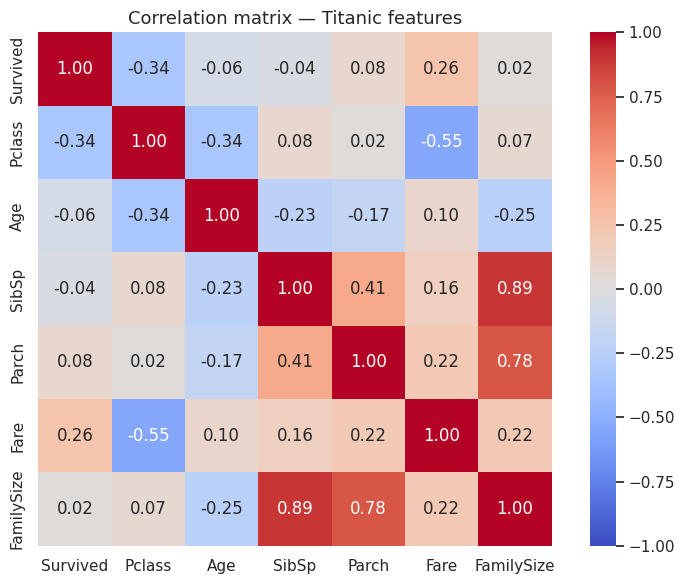


Correlation with Survived:
Survived      1.000
Fare          0.257
Parch         0.082
FamilySize    0.017
SibSp        -0.035
Age          -0.065
Pclass       -0.338
Name: Survived, dtype: float64


In [9]:
numeric_cols = df[["Survived", "Pclass", "Age",
                   "SibSp", "Parch", "Fare", "FamilySize"]]

corr_matrix = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix,
            annot=True,        # show numbers inside cells
            fmt=".2f",          # 2 decimal places
            cmap="coolwarm",   # blue=negative, red=positive
            center=0,           # white at zero
            vmin=-1, vmax=1,   # full -1 to +1 scale
            square=True)
plt.title("Correlation matrix — Titanic features", fontsize=13)
plt.tight_layout()
plt.show()

# Print correlation with target (Survived) only
print("\nCorrelation with Survived:")
print(corr_matrix["Survived"].sort_values(ascending=False).round(3))
